In [70]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,accuracy_score
import pickle
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn import datasets
import matplotlib.pyplot as plt
import kagglehub

Loading dataset : https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database

In [59]:
# Download latest version
path = kagglehub.dataset_download("uciml/pima-indians-diabetes-database")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\Emilien JEMELEN\.cache\kagglehub\datasets\uciml\pima-indians-diabetes-database\versions\1


In [60]:
diabetes_ds = pd.read_csv('C:/Users/Emilien JEMELEN/Documents/diabetes.csv')
diabetes_ds.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [61]:
diabetes_ds.shape

(768, 9)

In [71]:
print('Proportion of 1s:', np.round(diabetes_ds.Outcome.sum()/diabetes_ds.shape[0],2))

Proportion of 1s: 0.35


#### some preprocessing

In [45]:
features = diabetes_ds.drop(['Outcome'], axis=1)
# missing values mean imputation
features = features.fillna(features.mean(numeric_only=True))
features.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [46]:
X = features
Y = diabetes_ds.Outcome

In [47]:
# split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.6, random_state=42, stratify=Y)

## <font color='yellow'> logistic regression

In [48]:
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [49]:
# On test set after model selection
test_pred = model.predict(X_test)
print(classification_report(Y_test, test_pred))
print('Test Accuracy:', accuracy_score(Y_test, test_pred))

              precision    recall  f1-score   support

           0       0.79      0.82      0.80       300
           1       0.63      0.58      0.61       161

    accuracy                           0.74       461
   macro avg       0.71      0.70      0.70       461
weighted avg       0.73      0.74      0.73       461

Test Accuracy: 0.735357917570499


### Retrieving $\kappa_f$ confidence function

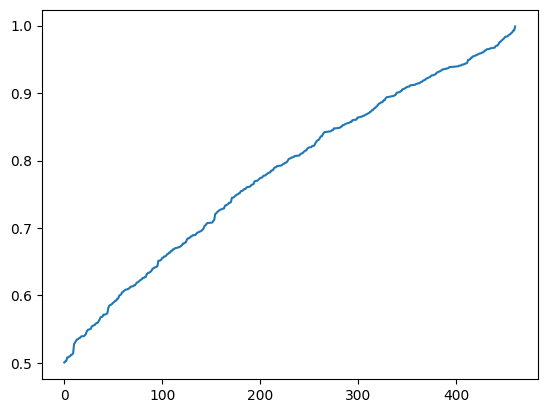

In [50]:
y_true = Y_test
y_pred = test_pred
kappa = model.predict_proba(X_test).max(axis=1)
plt.plot(sorted(kappa))

In [51]:
sgr_df = pd.DataFrame({'y_true': y_true,
              'y_pred': y_pred,
              'kappa': kappa}).sort_values('kappa')
sgr_df

,y_true,y_pred,kappa
473,0,0,0.500446
293,1,0,0.502096
199,1,0,0.502561
560,1,0,0.507841
298,1,1,0.507906
...,...,...,...
494,0,0,0.988874
502,1,0,0.990137
81,0,0,0.992580
349,1,0,0.992978


In [52]:
pickle.dump(sgr_df, open('sgr_set_log_reg','wb'))

## <font color='yellow'> SVM classifier (linear kernel)

In [53]:
model = SVC(kernel='linear', C=1.0, probability=True)  # C is the regularization parameter
model.fit(X_train, Y_train)


,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [54]:
# Predict and evaluate
Y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(Y_test, Y_pred))
print(classification_report(Y_test, Y_pred))

Accuracy: 0.7483731019522777
              precision    recall  f1-score   support

           0       0.78      0.85      0.81       300
           1       0.67      0.56      0.61       161

    accuracy                           0.75       461
   macro avg       0.72      0.70      0.71       461
weighted avg       0.74      0.75      0.74       461



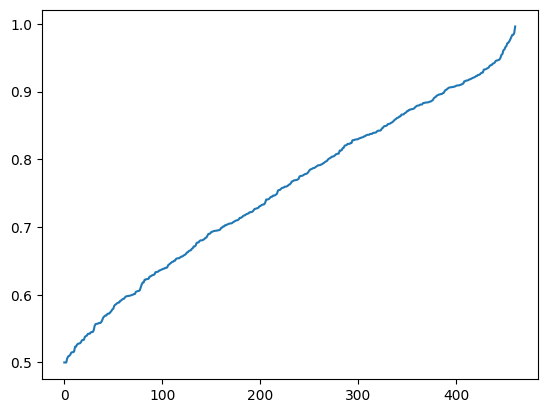

In [55]:
kappa = model.predict_proba(X_test).max(axis=1)
plt.plot(sorted(kappa))

In [56]:
sgr_df = pd.DataFrame({'y_true': Y_test,
                       'y_pred': Y_pred,
                       'kappa': kappa}).sort_values('kappa')
sgr_df

,y_true,y_pred,kappa
648,1,0,0.500000
345,0,1,0.500000
267,0,1,0.500000
578,0,1,0.506043
517,0,0,0.508941
...,...,...,...
537,0,0,0.980313
81,0,0,0.983561
502,1,0,0.983737
349,1,0,0.986185


In [57]:
pickle.dump(sgr_df, open('sgr_set_svm','wb'))